
Enter your sleep details (or press ENTER for default values):



Sleep duration (hours) [default 7.5]:  5
Caffeine intake (mg) [default 120]:  
Stress level (0-5) [default 3]:  3
Bedtime consistency (0-1) [default 0.9]:  0.4


C:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



===== Your Sleep Score Result =====
Sleep Duration (hrs)  : 5.0
Caffeine Intake (mg)  : 120.0
Stress Level          : 3.0
Bedtime Consistency   : 0.4
-----------------------------------
Predicted Sleep Score : 3.07 / 10
Interpretation         :  Poor Sleep Quality



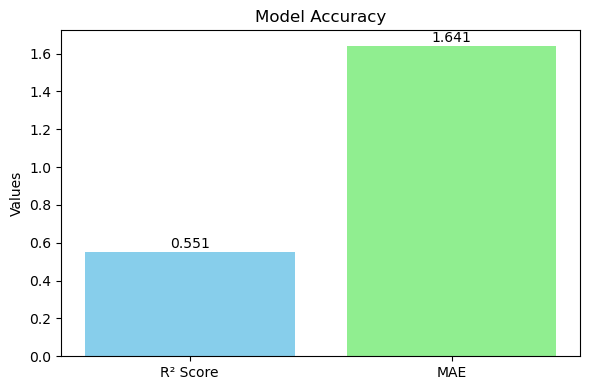

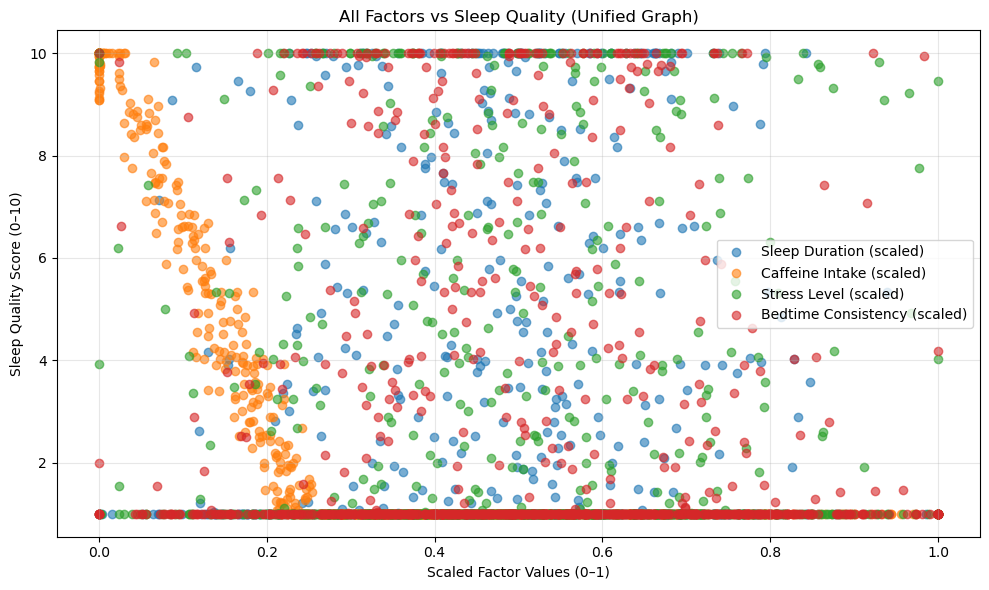

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

CSV = "wearable_tech_sleep_quality_1.csv"

def load_data():
    df = pd.read_csv(CSV)
    cols = ["Sleep_Duration_Hours", "Sleep_Quality_Score", "Caffeine_Intake_mg",
            "Stress_Level", "Bedtime_Consistency"]
    for c in cols:
        if c not in df.columns:
            raise ValueError(f"Missing column: {c}")
    return df[cols].dropna()

def train_model(df):
    X = df[["Sleep_Duration_Hours", "Caffeine_Intake_mg", "Stress_Level", "Bedtime_Consistency"]]
    y = df["Sleep_Quality_Score"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return model, X, y, r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred)

def interpret_score(s):
    s = round(s, 2)
    if s >= 8:
        return s, " Excellent Sleep Quality"
    elif s >= 6:
        return s, " Good Sleep Quality"
    elif s >= 4:
        return s, " Average Sleep Quality"
    else:
        return s, " Poor Sleep Quality"

def get_input(prompt, cast=float, default=None):
    try:
        inp = input(prompt)
        if inp.strip() == "" and default is not None:
            return default
        return cast(inp)
    except:
        print("Invalid input.")
        return get_input(prompt, cast, default)

def main():

    df = load_data()
    model, X, y, r2, mae = train_model(df)

    print("\nEnter your sleep details (or press ENTER for default values):\n")

    sd = get_input("Sleep duration (hours) [default 7.5]: ", float, 7.5)
    caf = get_input("Caffeine intake (mg) [default 120]: ", float, 120.0)
    stress = get_input("Stress level (0-5) [default 3]: ", float, 3.0)
    consistency = get_input("Bedtime consistency (0-1) [default 0.9]: ", float, 0.9)

    pred = model.predict([[sd, caf, stress, consistency]])[0]
    pred = max(0, min(10, pred))  # keep within 0–10 scale
    score, label = interpret_score(pred)

    print("\n===== Your Sleep Score Result =====")
    print(f"Sleep Duration (hrs)  : {sd}")
    print(f"Caffeine Intake (mg)  : {caf}")
    print(f"Stress Level          : {stress}")
    print(f"Bedtime Consistency   : {consistency}")
    print("-----------------------------------")
    print(f"Predicted Sleep Score : {score} / 10")
    print(f"Interpretation         : {label}")
    print("===================================\n")


    plt.figure(figsize=(6,4))
    metrics = ["R² Score", "MAE"]
    values = [r2, mae]

    plt.bar(metrics, values, color=["skyblue", "lightgreen"])
    plt.title("Model Accuracy")
    plt.ylabel("Values")
    for i,v in enumerate(values):
        plt.text(i, v + 0.02, f"{v:.3f}", ha='center')

    plt.tight_layout()
    plt.show()


    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X[["Sleep_Duration_Hours", 
                                       "Caffeine_Intake_mg", 
                                       "Stress_Level", 
                                       "Bedtime_Consistency"]])
    scaled_df = pd.DataFrame(X_scaled, columns=["Sleep_Duration_Hours",
                                                "Caffeine_Intake_mg",
                                                "Stress_Level",
                                                "Bedtime_Consistency"])

    plt.figure(figsize=(10,6))

    plt.scatter(scaled_df["Sleep_Duration_Hours"], y, label="Sleep Duration (scaled)", alpha=0.6)
    plt.scatter(scaled_df["Caffeine_Intake_mg"], y, label="Caffeine Intake (scaled)", alpha=0.6)
    plt.scatter(scaled_df["Stress_Level"], y, label="Stress Level (scaled)", alpha=0.6)
    plt.scatter(scaled_df["Bedtime_Consistency"], y, label="Bedtime Consistency (scaled)", alpha=0.6)

    plt.title("All Factors vs Sleep Quality (Unified Graph)")
    plt.xlabel("Scaled Factor Values (0–1)")
    plt.ylabel("Sleep Quality Score (0–10)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()
